## 1 Import all the required libraries

Pandas → data handling

Seaborn/Matplotlib → visualization

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

## 2 Load Dataset

Columns loaded correctly

Any strange values

In [16]:
df = pd.read_csv("E:/EDA/customer_churn/data/Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3 3: Basic Data Overview

Number of rows (~7043)

Data types (object, int, float)

Any missing values

In [17]:
df.shape

(7043, 21)

In [18]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4: Statistical Summary

Mean, min, max

Any impossible values (e.g., negative charges)

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## STEP 5: Missing Value Analysis

In [21]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## STEP 6: Target Variable Analysis (Churn)

In [22]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [23]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### Visualization
📌 Business Insight

Around 26–27% customers have churned → class imbalance exists.

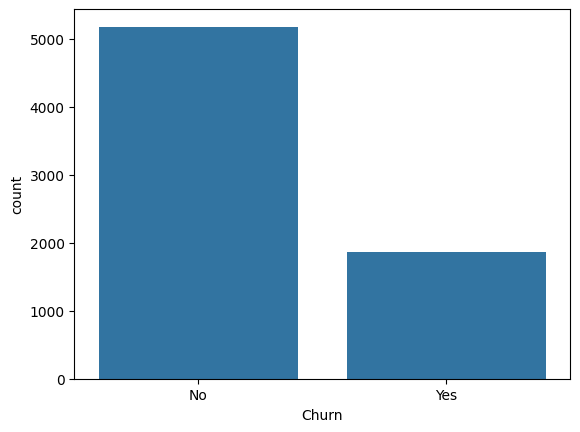

In [25]:
sns.countplot(x='Churn', data=df)
plt.show()

## STEP 7: Univariate Analysis (Numerical Features)

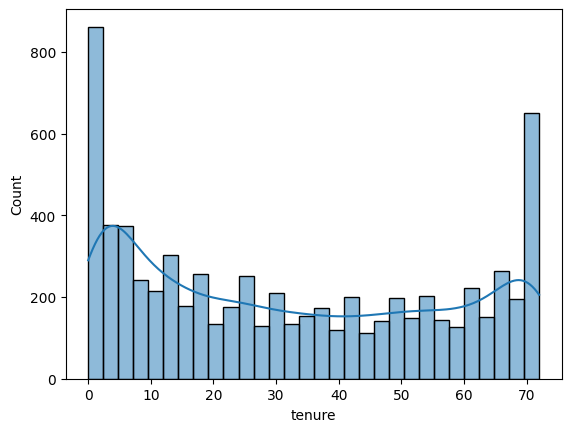

In [27]:
sns.histplot(df['tenure'], bins=30, kde=True)
plt.show()

📌 Insight:

Many customers churn early (low tenure).

### Monthly Charges

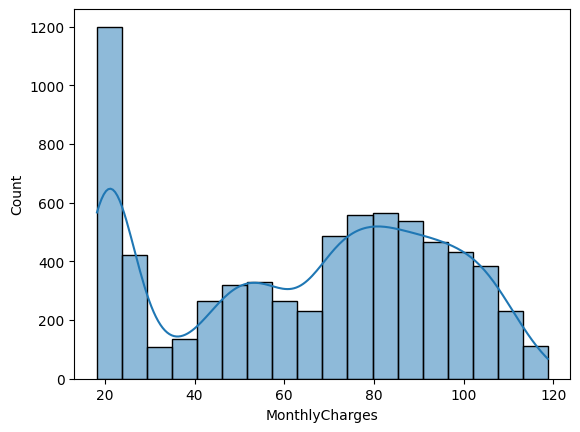

In [29]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

### Box Plot (Outliers)

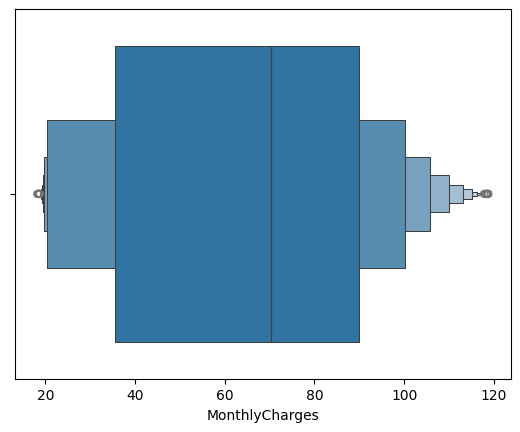

In [31]:
sns.boxenplot(x=df['MonthlyCharges'])
plt.show()

📌 Insight:

Charges are slightly right-skewed, no extreme outliers.

## STEP 8: Univariate Analysis (Categorical Features)

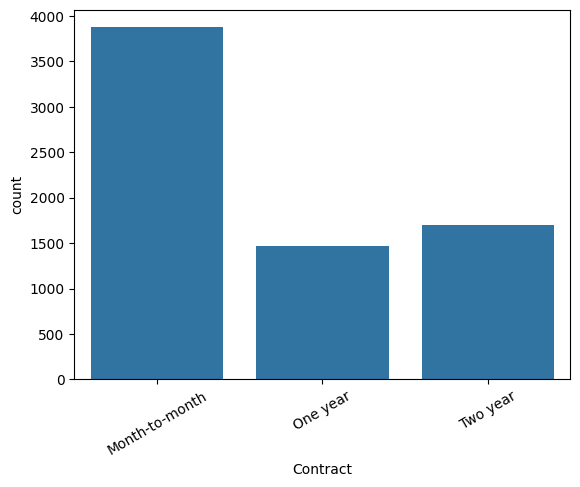

In [36]:
sns.countplot(x='Contract', data=df)
plt.xticks(rotation=30)
plt.show()

📌 Insight:

Month-to-month contracts dominate.

### Payment Method

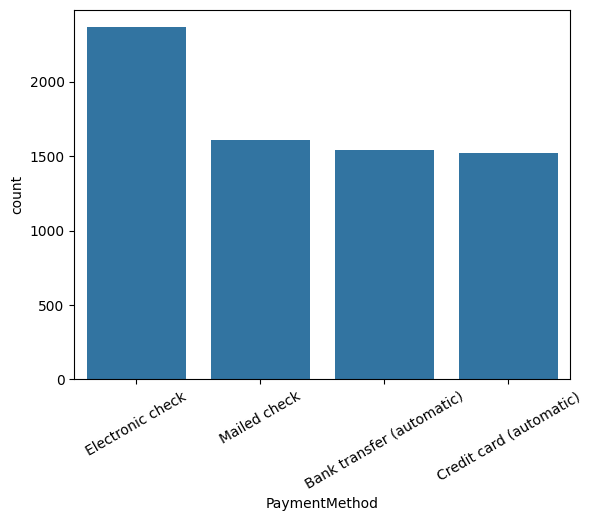

In [39]:
sns.countplot(x='PaymentMethod', data=df)
plt.xticks(rotation=30)
plt.show()

## STEP 9: Bivariate Analysis (Feature vs Churn)

Tenure vs Churn

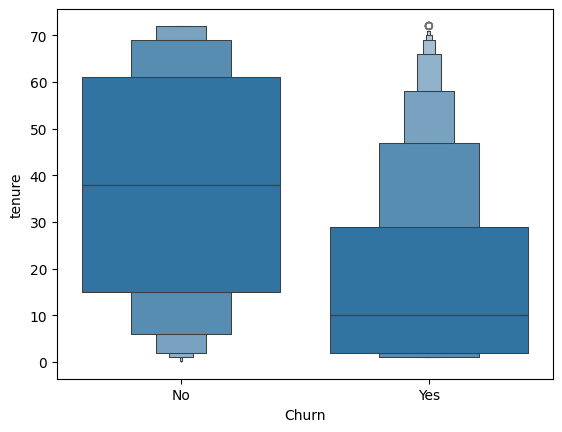

In [41]:
sns.boxenplot(x='Churn', y='tenure', data=df)
plt.show()

📌 Insight:

Customers who churn have significantly lower tenure.

### Monthly Charges vs Churn

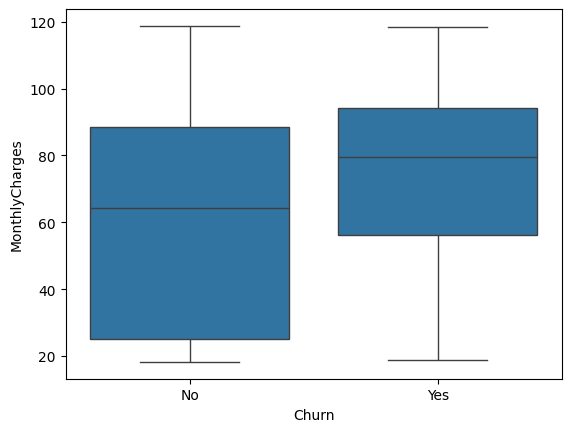

In [45]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

📌 Insight:

Higher monthly charges → higher churn probability.

### Contract vs Churn

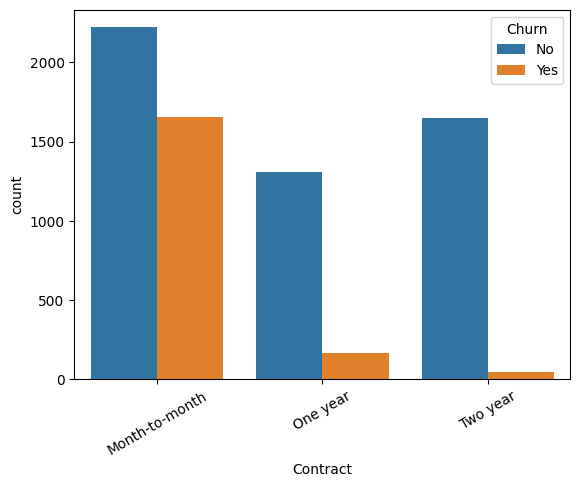

In [47]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

📌 Insight:

Month-to-month customers churn the most.

### Payment Method vs Churn

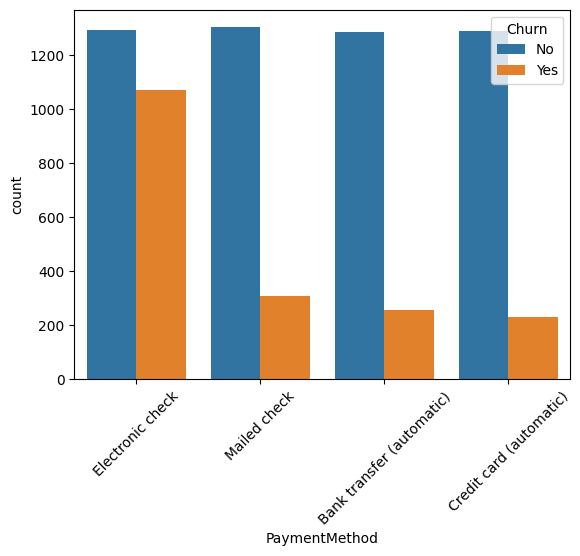

In [49]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

📌 Insight:

Electronic check users show higher churn.

## STEP 10: Correlation Analysis

In [54]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

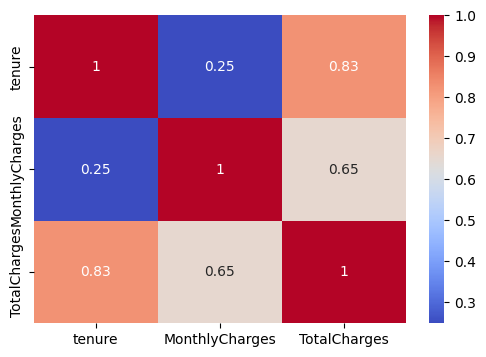

In [57]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

📌 Insight:

Tenure and TotalCharges are highly correlated.

## STEP 11: Multivariate Insight

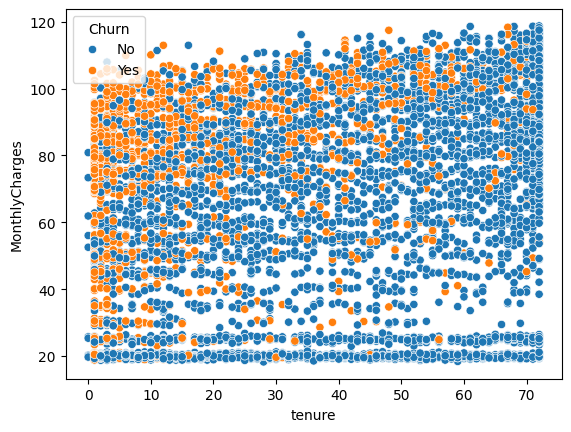

<Figure size 500x300 with 0 Axes>

In [62]:
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

High charges + low tenure → churn cluster visible.

## STEP 12: Data Quality Checks

In [63]:
df.duplicated().sum()

np.int64(0)

In [65]:
df['customerID'].nunique() == df.shape[0]

True

📌 Insight:

No duplicate customers.

## STEP 13: EDA Summary (VERY IMPORTANT)

1. Churn rate is ~26%
2. Month-to-month contracts show highest churn
3. Customers with low tenure churn more
4. High monthly charges increase churn risk
5. Long-term contracts reduce churn
